In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

# --------------------------------------------------
# Paths
# --------------------------------------------------

PROCESSED_DIR = Path("../data/processed")

TRAIN_FILE = PROCESSED_DIR / "train_dos.csv"
VAL_FILE = PROCESSED_DIR / "validation_dos.csv"
TEST_FILE = PROCESSED_DIR / "test_dos.csv"

# --------------------------------------------------
# Load datasets
# --------------------------------------------------

train_df = pd.read_csv(TRAIN_FILE)
val_df = pd.read_csv(VAL_FILE)
test_df = pd.read_csv(TEST_FILE)

print("✅ Datasets loaded")
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

✅ Datasets loaded
Train: (721712, 69)
Validation: (154653, 69)
Test: (154653, 69)


In [2]:
# Separate input features (X) and target (y)

X_train = train_df.drop(columns=["Target"])
y_train = train_df["Target"]

X_val = val_df.drop(columns=["Target"])
y_val = val_df["Target"]

X_test = test_df.drop(columns=["Target"])
y_test = test_df["Target"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (721712, 68)
y_train: (721712,)
X_val: (154653, 68)
y_val: (154653,)
X_test: (154653, 68)
y_test: (154653,)


In [3]:
non_numeric = X_train.select_dtypes(exclude=np.number).columns.tolist()

print("Non-numeric feature columns:")
print(non_numeric)

Non-numeric feature columns:
[]


In [4]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

baseline_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "classifier",
        LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            solver="lbfgs",
            n_jobs=None
        )
    )
])

print("✅ Baseline pipeline created")

✅ Baseline pipeline created


In [5]:
import time

start_time = time.perf_counter()

baseline_model.fit(X_train, y_train)

training_time = time.perf_counter() - start_time

print(f"Baseline model trained in {training_time:.2f} seconds")

Baseline model trained in 2.81 seconds


In [6]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

start_time = time.perf_counter()

y_val_pred = baseline_model.predict(X_val)

inference_time = time.perf_counter() - start_time

accuracy = accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)

tn, fp, fn, tp = confusion_matrix(
    y_val,
    y_val_pred
).ravel()

false_positive_rate = fp / (fp + tn)

print("===== BASELINE VALIDATION RESULTS =====")
print(f"Accuracy:          {accuracy:.4f}")
print(f"Precision:         {precision:.4f}")
print(f"Recall:            {recall:.4f}")
print(f"F1 Score:          {f1:.4f}")
print(f"False Positive Rate:{false_positive_rate:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))

print(f"\nValidation inference time: {inference_time:.2f} sec")

===== BASELINE VALIDATION RESULTS =====
Accuracy:          1.0000
Precision:         1.0000
Recall:            1.0000
F1 Score:          1.0000
False Positive Rate:0.0000

Confusion Matrix:
[[78669     0]
 [    0 75984]]

Validation inference time: 0.14 sec


In [7]:
# How confident is the baseline?

y_val_proba = baseline_model.predict_proba(X_val)[:, 1]

print("Minimum confidence:", y_val_proba.min())
print("Maximum confidence:", y_val_proba.max())

print("\nProbability summary:")
print(pd.Series(y_val_proba).describe())

Minimum confidence: 5.942220438289732e-99
Maximum confidence: 0.9998933662360343

Probability summary:
count    1.546530e+05
mean     4.912233e-01
std      4.998283e-01
min      5.942220e-99
25%      1.518275e-07
50%      3.349149e-07
75%      9.998080e-01
max      9.998934e-01
dtype: float64


In [8]:
# Get feature importance from Logistic Regression
# Larger absolute coefficient = stronger influence after scaling.

logreg = baseline_model.named_steps["classifier"]

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": logreg.coef_[0],
    "Abs_Coefficient": np.abs(logreg.coef_[0])
})

feature_importance = feature_importance.sort_values(
    "Abs_Coefficient",
    ascending=False
)

display(feature_importance.head(20))

,Feature,Coefficient,Abs_Coefficient
57,Init Bwd Win Byts,-1.119365,1.119365
0,Dst Port,-1.119154,1.119154
48,Down/Up Ratio,0.945750,0.945750
52,Subflow Fwd Pkts,-0.876411,0.876411
3,Tot Fwd Pkts,-0.876411,0.876411
7,Fwd Pkt Len Max,-0.872260,0.872260
5,TotLen Fwd Pkts,-0.871990,0.871990
53,Subflow Fwd Byts,-0.871990,0.871990
32,Fwd Header Len,-0.836744,0.836744
10,Fwd Pkt Len Std,-0.778888,0.778888


In [9]:
top_features = feature_importance.head(5)["Feature"].tolist()

print("Top 5 features:")
for feature in top_features:
    print("-", feature)

Top 5 features:
- Init Bwd Win Byts
- Dst Port
- Down/Up Ratio
- Subflow Fwd Pkts
- Tot Fwd Pkts


In [10]:
from sklearn.metrics import f1_score

for feature in top_features:
    model = Pipeline([
        ("scaler", StandardScaler()),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000
            )
        )
    ])

    model.fit(
        X_train[[feature]],
        y_train
    )

    pred = model.predict(X_val[[feature]])

    print(
        f"{feature:30} "
        f"F1 = {f1_score(y_val, pred):.4f}"
    )

Init Bwd Win Byts              F1 = 0.9999
Dst Port                       F1 = 0.9999
Down/Up Ratio                  F1 = 0.0000
Subflow Fwd Pkts               F1 = 1.0000
Tot Fwd Pkts                   F1 = 1.0000


In [11]:
# Check whether validation rows contain exact feature vectors
# already seen during training.

train_hashes = pd.util.hash_pandas_object(
    X_train,
    index=False
)

val_hashes = pd.util.hash_pandas_object(
    X_val,
    index=False
)

overlap = len(
    set(train_hashes).intersection(set(val_hashes))
)

print("Exact feature-vector overlap:", overlap)

Exact feature-vector overlap: 13469


In [12]:
# Load the original test split so we can inspect
# the actual attack types.

RAW_FILE = "../data/raw/Wednesday-21-02-2018_TrafficForML_CICFlowMeter.csv"

raw_df = pd.read_csv(RAW_FILE)

raw_df["Timestamp"] = pd.to_datetime(
    raw_df["Timestamp"],
    format="%d/%m/%Y %H:%M:%S",
    errors="coerce"
)

raw_df = raw_df.drop_duplicates()
raw_df = raw_df.sort_values("Timestamp").reset_index(drop=True)

n = len(raw_df)
test_start = int(n * 0.85)

raw_test = raw_df.iloc[test_start:].copy()

print("Test-set labels:")
print(raw_test["Label"].value_counts())

Test-set labels:
Label
Benign                  80794
DDOS attack-HOIC        72129
DDOS attack-LOIC-UDP     1730
Name: count, dtype: int64


In [13]:
# ============================================================
# OVERLAP AUDIT
# Are the same feature vectors appearing in Train and Val?
# And do they always have the same label?
# ============================================================

import pandas as pd

# Hash feature vectors (excluding Target)
train_hash = pd.util.hash_pandas_object(
    X_train,
    index=False
)

val_hash = pd.util.hash_pandas_object(
    X_val,
    index=False
)

train_lookup = pd.DataFrame({
    "hash": train_hash,
    "label": y_train.to_numpy()
})

val_lookup = pd.DataFrame({
    "hash": val_hash,
    "label": y_val.to_numpy()
})

# Keep only validation hashes that also occur in training
overlap_hashes = set(train_lookup["hash"]).intersection(
    set(val_lookup["hash"])
)

overlap_val = val_lookup[
    val_lookup["hash"].isin(overlap_hashes)
].copy()

# For each overlapping feature vector, check the labels seen in training
train_label_map = (
    train_lookup[
        train_lookup["hash"].isin(overlap_hashes)
    ]
    .groupby("hash")["label"]
    .agg(lambda x: sorted(set(x)))
)

overlap_val["train_labels"] = overlap_val["hash"].map(train_label_map)

# Count whether validation labels agree with training labels
overlap_val["label_match"] = overlap_val.apply(
    lambda row: row["label"] in row["train_labels"],
    axis=1
)

print("Exact overlapping feature-vector rows:", len(overlap_val))
print(
    "Overlapping rows whose label also exists in training:",
    overlap_val["label_match"].sum()
)
print(
    "Overlapping rows with a conflicting label:",
    (~overlap_val["label_match"]).sum()
)

Exact overlapping feature-vector rows: 74264
Overlapping rows whose label also exists in training: 74264
Overlapping rows with a conflicting label: 0


In [14]:
test_hash = pd.util.hash_pandas_object(
    X_test,
    index=False
)

train_hash_set = set(train_hash)

test_overlap = sum(
    h in train_hash_set
    for h in test_hash
)

print("Exact Train-Test feature-vector overlap:", test_overlap)

Exact Train-Test feature-vector overlap: 70560


In [15]:
# ============================================================
# SINGLE-FEATURE STRESS TEST
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

single_feature_results = []

for feature in X_train.columns:

    model = Pipeline([
        ("scaler", StandardScaler()),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000
            )
        )
    ])

    model.fit(
        X_train[[feature]],
        y_train
    )

    pred = model.predict(
        X_val[[feature]]
    )

    score = f1_score(
        y_val,
        pred
    )

    single_feature_results.append(
        (feature, score)
    )

single_feature_results = sorted(
    single_feature_results,
    key=lambda x: x[1],
    reverse=True
)

print("Top 20 single features:")
for feature, score in single_feature_results[:20]:
    print(f"{feature:35} F1 = {score:.4f}")

Top 20 single features:
Tot Fwd Pkts                        F1 = 1.0000
Subflow Fwd Pkts                    F1 = 1.0000
ACK Flag Cnt                        F1 = 1.0000
Fwd Act Data Pkts                   F1 = 1.0000
TotLen Fwd Pkts                     F1 = 1.0000
Subflow Fwd Byts                    F1 = 1.0000
Tot Bwd Pkts                        F1 = 0.9999
Bwd Header Len                      F1 = 0.9999
Subflow Bwd Pkts                    F1 = 0.9999
Fwd Pkt Len Mean                    F1 = 0.9999
Fwd Header Len                      F1 = 0.9999
Fwd Seg Size Avg                    F1 = 0.9999
Bwd Pkt Len Mean                    F1 = 0.9999
Pkt Len Max                         F1 = 0.9999
Pkt Len Mean                        F1 = 0.9999
PSH Flag Cnt                        F1 = 0.9999
Pkt Size Avg                        F1 = 0.9999
Bwd Seg Size Avg                    F1 = 0.9999
Fwd Pkt Len Max                     F1 = 0.9999
Dst Port                            F1 = 0.9999


In [16]:
behavior_features = [
    "Flow Duration",
    "Tot Fwd Pkts",
    "Tot Bwd Pkts",
    "Flow Byts/s",
    "Flow Pkts/s",
    "SYN Flag Cnt",
    "ACK Flag Cnt",
    "RST Flag Cnt",
    "Down/Up Ratio",
    "Flow IAT Mean",
    "Flow IAT Std",
    "Fwd Pkt Len Mean",
    "Bwd Pkt Len Mean"
]

behavior_features = [
    f for f in behavior_features
    if f in X_train.columns
]

print("Using:", len(behavior_features), "behavioral features")
print(behavior_features)

Using: 13 behavioral features
['Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'Flow Byts/s', 'Flow Pkts/s', 'SYN Flag Cnt', 'ACK Flag Cnt', 'RST Flag Cnt', 'Down/Up Ratio', 'Flow IAT Mean', 'Flow IAT Std', 'Fwd Pkt Len Mean', 'Bwd Pkt Len Mean']


In [17]:
behavior_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "classifier",
        LogisticRegression(
            class_weight="balanced",
            max_iter=1000
        )
    )
])

behavior_model.fit(
    X_train[behavior_features],
    y_train
)

behavior_pred = behavior_model.predict(
    X_val[behavior_features]
)

behavior_f1 = f1_score(
    y_val,
    behavior_pred
)

print(f"Behavior-only baseline F1: {behavior_f1:.4f}")

Behavior-only baseline F1: 1.0000


In [18]:
# Feature columns only — Target is not an input feature
feature_columns = X_train.columns.tolist()

print("Number of model features:", len(feature_columns))

Number of model features: 68


In [19]:
# Combine the three partitions so we can remove
# repeated feature vectors BEFORE making a new benchmark split.

all_model_data = pd.concat(
    [
        train_df,
        val_df,
        test_df
    ],
    ignore_index=True
)

print("Combined rows:", len(all_model_data))
print("Columns:", len(all_model_data.columns))

Combined rows: 1031018
Columns: 69


In [20]:
# Remove rows with identical ML feature vectors.
# This prevents the exact same input pattern from appearing
# in different partitions.

before = len(all_model_data)

unique_model_data = (
    all_model_data
    .drop_duplicates(subset=feature_columns)
    .reset_index(drop=True)
)

after = len(unique_model_data)

print("Rows before feature-vector deduplication:", before)
print("Rows after feature-vector deduplication:", after)
print("Feature-vector duplicates removed:", before - after)

Rows before feature-vector deduplication: 1031018
Rows after feature-vector deduplication: 561405
Feature-vector duplicates removed: 469613


In [21]:
print(
    unique_model_data["Target"]
    .value_counts()
)

print("\nPercentages:")

print(
    unique_model_data["Target"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Target
0    360814
1    200591
Name: count, dtype: int64

Percentages:
Target
0    64.27
1    35.73
Name: proportion, dtype: float64


In [22]:
print("Unique feature-vector dataset shape:",
      unique_model_data.shape)

Unique feature-vector dataset shape: (561405, 69)


In [23]:
from sklearn.model_selection import train_test_split

strict_train, strict_temp = train_test_split(
    unique_model_data,
    test_size=0.30,
    stratify=unique_model_data["Target"],
    random_state=42
)

strict_val, strict_test = train_test_split(
    strict_temp,
    test_size=0.50,
    stratify=strict_temp["Target"],
    random_state=42
)

print("Strict Train:", strict_train.shape)
print("Strict Validation:", strict_val.shape)
print("Strict Test:", strict_test.shape)

Strict Train: (392983, 69)
Strict Validation: (84211, 69)
Strict Test: (84211, 69)


In [24]:
X_strict_train = strict_train[feature_columns]
X_strict_val = strict_val[feature_columns]
X_strict_test = strict_test[feature_columns]

train_hashes = set(
    pd.util.hash_pandas_object(
        X_strict_train,
        index=False
    )
)

val_hashes = set(
    pd.util.hash_pandas_object(
        X_strict_val,
        index=False
    )
)

test_hashes = set(
    pd.util.hash_pandas_object(
        X_strict_test,
        index=False
    )
)

print(
    "Train-Val overlap:",
    len(train_hashes.intersection(val_hashes))
)

print(
    "Train-Test overlap:",
    len(train_hashes.intersection(test_hashes))
)

print(
    "Val-Test overlap:",
    len(val_hashes.intersection(test_hashes))
)

Train-Val overlap: 0
Train-Test overlap: 0
Val-Test overlap: 0


In [25]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

strict_baseline = Pipeline([
    ("scaler", StandardScaler()),
    (
        "classifier",
        LogisticRegression(
            class_weight="balanced",
            max_iter=1000
        )
    )
])

strict_baseline.fit(
    X_strict_train,
    strict_train["Target"]
)

strict_val_pred = strict_baseline.predict(
    X_strict_val
)

In [26]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

accuracy = accuracy_score(
    strict_val["Target"],
    strict_val_pred
)

precision = precision_score(
    strict_val["Target"],
    strict_val_pred
)

recall = recall_score(
    strict_val["Target"],
    strict_val_pred
)

f1 = f1_score(
    strict_val["Target"],
    strict_val_pred
)

tn, fp, fn, tp = confusion_matrix(
    strict_val["Target"],
    strict_val_pred
).ravel()

fpr = fp / (fp + tn)

print("===== STRICT BASELINE =====")
print(f"Accuracy:           {accuracy:.4f}")
print(f"Precision:          {precision:.4f}")
print(f"Recall:             {recall:.4f}")
print(f"F1:                 {f1:.4f}")
print(f"False Positive Rate:{fpr:.4f}")

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        strict_val["Target"],
        strict_val_pred
    )
)

===== STRICT BASELINE =====
Accuracy:           1.0000
Precision:          0.9999
Recall:             1.0000
F1:                 1.0000
False Positive Rate:0.0001

Confusion Matrix:
[[54119     3]
 [    0 30089]]


In [27]:
# ============================================================
# FEATURE SEPARABILITY ANALYSIS
# Compare the strongest features between Benign and DDoS.
# We use validation data only for this diagnostic.
# ============================================================

diagnostic_features = [
    "Tot Fwd Pkts",
    "Subflow Fwd Pkts",
    "ACK Flag Cnt",
    "Fwd Act Data Pkts",
    "TotLen Fwd Pkts",
    "Dst Port",
    "Flow Pkts/s",
    "Flow Byts/s"
]

diagnostic_features = [
    f for f in diagnostic_features
    if f in X_strict_val.columns
]

for feature in diagnostic_features:
    print(f"\n===== {feature} =====")

    summary = (
        strict_val
        .groupby("Target")[feature]
        .agg(
            ["count", "min", "median", "mean", "max", "std"]
        )
    )

    print(summary)


===== Tot Fwd Pkts =====
        count  min  median         mean     max           std
Target                                                       
0       54122    1     5.0     5.036233     148      0.923627
1       30089    2     3.0  1080.709429  309629  11574.156016

===== Subflow Fwd Pkts =====
        count  min  median         mean     max           std
Target                                                       
0       54122    1     5.0     5.036233     148      0.923627
1       30089    2     3.0  1080.709429  309629  11574.156016

===== ACK Flag Cnt =====
        count  min  median      mean  max       std
Target                                             
0       54122    0     0.0  0.000222    1  0.014889
1       30089    0     0.0  0.178171    1  0.382663

===== Fwd Act Data Pkts =====
        count  min  median         mean     max           std
Target                                                       
0       54122    0     1.0     1.054987     146      1.0553

In [28]:
# ============================================================
# RANGE OVERLAP CHECK
# ============================================================

for feature in diagnostic_features:

    benign_values = strict_val.loc[
        strict_val["Target"] == 0,
        feature
    ]

    ddos_values = strict_val.loc[
        strict_val["Target"] == 1,
        feature
    ]

    benign_min = benign_values.min()
    benign_max = benign_values.max()

    ddos_min = ddos_values.min()
    ddos_max = ddos_values.max()

    overlap_min = max(benign_min, ddos_min)
    overlap_max = min(benign_max, ddos_max)

    if overlap_min <= overlap_max:
        overlap = True
    else:
        overlap = False

    print(
        f"{feature:25} "
        f"Benign=[{benign_min:.3g}, {benign_max:.3g}] "
        f"DDoS=[{ddos_min:.3g}, {ddos_max:.3g}] "
        f"Range overlap={overlap}"
    )

Tot Fwd Pkts              Benign=[1, 148] DDoS=[2, 3.1e+05] Range overlap=True
Subflow Fwd Pkts          Benign=[1, 148] DDoS=[2, 3.1e+05] Range overlap=True
ACK Flag Cnt              Benign=[0, 1] DDoS=[0, 1] Range overlap=True
Fwd Act Data Pkts         Benign=[0, 146] DDoS=[0, 3.1e+05] Range overlap=True
TotLen Fwd Pkts           Benign=[0, 1.35e+04] DDoS=[0, 9.91e+06] Range overlap=True
Dst Port                  Benign=[0, 6.55e+04] DDoS=[80, 80] Range overlap=True
Flow Pkts/s               Benign=[0.0255, 2e+05] DDoS=[25.6, 6.67e+05] Range overlap=True
Flow Byts/s               Benign=[0, 1.93e+06] DDoS=[0, 1.76e+06] Range overlap=True


In [29]:
# Distribution of Total Forward Packets by class

display(
    strict_val
    .groupby("Target")["Tot Fwd Pkts"]
    .describe()
)

,count,mean,std,min,25%,50%,75%,max
Target,,,,,,,,
0,54122.0,5.036233,0.923627,1.0,5.0,5.0,5.0,148.0
1,30089.0,1080.709429,11574.156016,2.0,3.0,3.0,3.0,309629.0


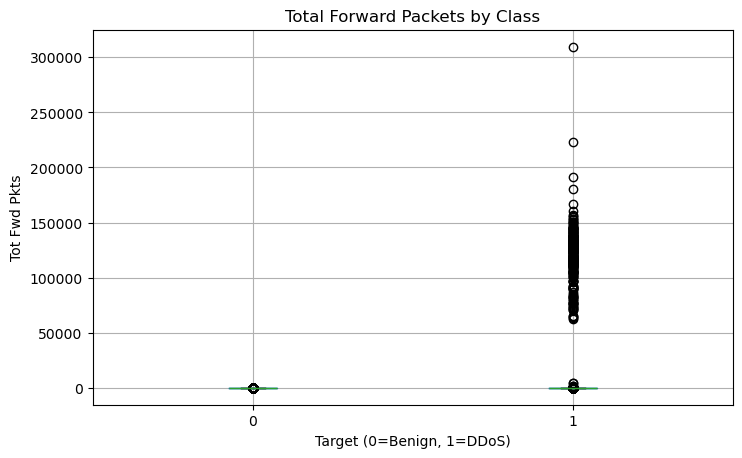

In [30]:
import matplotlib.pyplot as plt

strict_val.boxplot(
    column="Tot Fwd Pkts",
    by="Target",
    figsize=(8, 5)
)

plt.title("Total Forward Packets by Class")
plt.suptitle("")
plt.xlabel("Target (0=Benign, 1=DDoS)")
plt.ylabel("Tot Fwd Pkts")
plt.show()

In [31]:
import pandas as pd
import numpy as np

RAW_FILE = "../data/raw/Wednesday-21-02-2018_TrafficForML_CICFlowMeter.csv"

df_raw = pd.read_csv(RAW_FILE)

df_raw["Timestamp"] = pd.to_datetime(
    df_raw["Timestamp"],
    format="%d/%m/%Y %H:%M:%S",
    errors="coerce"
)

df_raw = df_raw.drop_duplicates().copy()

print("Rows after duplicate removal:", len(df_raw))
print(df_raw["Label"].value_counts())

Rows after duplicate removal: 1031018
Label
DDOS attack-HOIC        668461
Benign                  360827
DDOS attack-LOIC-UDP      1730
Name: count, dtype: int64


In [32]:
loic = df_raw[
    df_raw["Label"].eq("DDOS attack-LOIC-UDP")
].copy()

print("LOIC start:", loic["Timestamp"].min())
print("LOIC end:", loic["Timestamp"].max())
print("LOIC rows:", len(loic))

LOIC start: 2018-02-21 10:08:51
LOIC end: 2018-02-21 10:43:16
LOIC rows: 1730


In [33]:
test_start_time = loic["Timestamp"].min()

generalization_test = df_raw[
    df_raw["Timestamp"] >= test_start_time
].copy()

generalization_train = df_raw[
    df_raw["Timestamp"] < test_start_time
].copy()

print("Generalization TRAIN:",
      generalization_train.shape)

print("Generalization TEST:",
      generalization_test.shape)

print("\nTRAIN labels:")
print(generalization_train["Label"].value_counts())

print("\nTEST labels:")
print(generalization_test["Label"].value_counts())


Generalization TRAIN: (1027609, 80)
Generalization TEST: (3409, 80)

TRAIN labels:
Label
DDOS attack-HOIC    668461
Benign              359148
Name: count, dtype: int64

TEST labels:
Label
DDOS attack-LOIC-UDP    1730
Benign                  1679
Name: count, dtype: int64


In [34]:
generalization_train["Target"] = (
    ~generalization_train["Label"]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("benign")
).astype(int)

generalization_test["Target"] = (
    ~generalization_test["Label"]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("benign")
).astype(int)

In [35]:
CONSTANT_FEATURES = [
    "Bwd PSH Flags",
    "Fwd URG Flags",
    "Bwd URG Flags",
    "CWE Flag Count",
    "Fwd Byts/b Avg",
    "Fwd Pkts/b Avg",
    "Fwd Blk Rate Avg",
    "Bwd Byts/b Avg",
    "Bwd Pkts/b Avg",
    "Bwd Blk Rate Avg"
]

DROP_COLUMNS = [
    "Timestamp",
    "Label"
]

train_gen = generalization_train.drop(
    columns=DROP_COLUMNS + CONSTANT_FEATURES,
    errors="ignore"
)

test_gen = generalization_test.drop(
    columns=DROP_COLUMNS + CONSTANT_FEATURES,
    errors="ignore"
)

X_gen_train = train_gen.drop(columns=["Target"])
y_gen_train = train_gen["Target"]

X_gen_test = test_gen.drop(columns=["Target"])
y_gen_test = test_gen["Target"]

print("X_train:", X_gen_train.shape)
print("X_test :", X_gen_test.shape)

X_train: (1027609, 68)
X_test : (3409, 68)


In [36]:
train_feature_hashes = pd.util.hash_pandas_object(
    X_gen_train,
    index=False
)

test_feature_hashes = pd.util.hash_pandas_object(
    X_gen_test,
    index=False
)

overlap = set(train_feature_hashes).intersection(
    set(test_feature_hashes)
)

print("Train-Test exact feature overlap:", len(overlap))

Train-Test exact feature overlap: 0


In [38]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Fresh baseline for the unseen-attack experiment
unseen_attack_baseline = Pipeline([
    ("scaler", StandardScaler()),
    (
        "classifier",
        LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            solver="lbfgs"
        )
    )
])

print("Unseen-attack baseline created")

Unseen-attack baseline created


In [39]:
import time

start = time.perf_counter()

unseen_attack_baseline.fit(
    X_gen_train,
    y_gen_train
)

training_time = time.perf_counter() - start

print(f"Training time: {training_time:.2f} seconds")

Training time: 3.89 seconds


In [40]:
start = time.perf_counter()

y_gen_pred = unseen_attack_baseline.predict(
    X_gen_test
)

y_gen_proba = unseen_attack_baseline.predict_proba(
    X_gen_test
)[:, 1]

inference_time = time.perf_counter() - start

print(f"Inference time: {inference_time:.4f} seconds")

Inference time: 0.0186 seconds


In [42]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

accuracy = accuracy_score(
    y_gen_test,
    y_gen_pred
)

precision = precision_score(
    y_gen_test,
    y_gen_pred
)

recall = recall_score(
    y_gen_test,
    y_gen_pred
)

f1 = f1_score(
    y_gen_test,
    y_gen_pred
)

tn, fp, fn, tp = confusion_matrix(
    y_gen_test,
    y_gen_pred
).ravel()

fpr = fp / (fp + tn)

print("UNSEEN-ATTACK GENERALIZATION TEST")

print(f"Accuracy:            {accuracy:.4f}")
print(f"Precision:           {precision:.4f}")
print(f"Recall:              {recall:.4f}")
print(f"F1 Score:            {f1:.4f}")
print(f"False Positive Rate: {fpr:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_gen_test, y_gen_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_gen_test,
        y_gen_pred,
        target_names=["Benign", "DDoS"]
    )
)

UNSEEN-ATTACK GENERALIZATION TEST
Accuracy:            0.4878
Precision:           0.0000
Recall:              0.0000
F1 Score:            0.0000
False Positive Rate: 0.0095

Confusion Matrix:
[[1663   16]
 [1730    0]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.49      0.99      0.66      1679
        DDoS       0.00      0.00      0.00      1730

    accuracy                           0.49      3409
   macro avg       0.25      0.50      0.33      3409
weighted avg       0.24      0.49      0.32      3409



In [43]:
# Show misclassified unseen-attack examples

misclassified = generalization_test.loc[
    y_gen_test.index[
        y_gen_test.to_numpy() != y_gen_pred
    ]
].copy()

print("Misclassified samples:", len(misclassified))

display(
    misclassified[
        ["Label", "Target"]
    ].head(20)
)

Misclassified samples: 1746


,Label,Target
277,DDOS attack-LOIC-UDP,1
278,DDOS attack-LOIC-UDP,1
279,DDOS attack-LOIC-UDP,1
280,DDOS attack-LOIC-UDP,1
282,DDOS attack-LOIC-UDP,1
283,DDOS attack-LOIC-UDP,1
284,DDOS attack-LOIC-UDP,1
285,DDOS attack-LOIC-UDP,1
286,DDOS attack-LOIC-UDP,1
288,DDOS attack-LOIC-UDP,1


In [44]:
# ============================================================
# HOIC vs LOIC FEATURE DISTRIBUTION
# Find which network behaviours change between attack types.
# ============================================================

important_features = [
    "Dst Port",
    "Protocol",
    "Flow Duration",
    "Tot Fwd Pkts",
    "Tot Bwd Pkts",
    "TotLen Fwd Pkts",
    "TotLen Bwd Pkts",
    "Flow Byts/s",
    "Flow Pkts/s",
    "Flow IAT Mean",
    "Flow IAT Std",
    "Fwd Pkt Len Mean",
    "Bwd Pkt Len Mean",
    "SYN Flag Cnt",
    "ACK Flag Cnt",
    "RST Flag Cnt",
    "Down/Up Ratio",
]

important_features = [
    f for f in important_features
    if f in df_raw.columns
]

# Compare HOIC and LOIC only
attack_comparison = df_raw[
    df_raw["Label"].isin([
        "DDOS attack-HOIC",
        "DDOS attack-LOIC-UDP"
    ])
]

summary = (
    attack_comparison
    .groupby("Label")[important_features]
    .median()
    .T
)

display(summary)

Label,DDOS attack-HOIC,DDOS attack-LOIC-UDP
Dst Port,80.000000,8.000000e+01
Protocol,6.000000,1.700000e+01
Flow Duration,6733.000000,1.197773e+08
Tot Fwd Pkts,2.000000,1.197585e+05
Tot Bwd Pkts,0.000000,0.000000e+00
TotLen Fwd Pkts,0.000000,3.832272e+06
TotLen Bwd Pkts,0.000000,0.000000e+00
Flow Byts/s,0.000000,3.252367e+04
Flow Pkts/s,474.962681,1.016365e+03
Flow IAT Mean,3244.000000,9.839071e+02


In [45]:
# Calculate the relative difference between HOIC and LOIC medians

difference = summary.copy()

difference["relative_difference"] = (
    (
        difference["DDOS attack-LOIC-UDP"]
        - difference["DDOS attack-HOIC"]
    ).abs()
    /
    (
        difference["DDOS attack-HOIC"].abs() + 1e-9
    )
)

difference = difference.sort_values(
    "relative_difference",
    ascending=False
)

display(difference)

Label,DDOS attack-HOIC,DDOS attack-LOIC-UDP,relative_difference
TotLen Fwd Pkts,0.000000,3.832272e+06,3.832272e+15
Flow Byts/s,0.000000,3.252367e+04,3.252367e+13
Flow IAT Std,0.000000,1.952671e+04,1.952671e+13
Fwd Pkt Len Mean,0.000000,3.200000e+01,3.200000e+10
Tot Fwd Pkts,2.000000,1.197585e+05,5.987825e+04
Flow Duration,6733.000000,1.197773e+08,1.778859e+04
Protocol,6.000000,1.700000e+01,1.833333e+00
Flow Pkts/s,474.962681,1.016365e+03,1.139883e+00
ACK Flag Cnt,1.000000,0.000000e+00,1.000000e+00
Flow IAT Mean,3244.000000,9.839071e+02,6.966994e-01


In [46]:
loic_mask = (
    generalization_test["Label"]
    == "DDOS attack-LOIC-UDP"
)

loic_features = test_gen.loc[
    loic_mask,
    X_gen_test.columns
]

loic_probability = (
    unseen_attack_baseline
    .predict_proba(loic_features)[:, 1]
)

print("LOIC probability summary:")
print(
    pd.Series(loic_probability).describe()
)

LOIC probability summary:
count    1730.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
dtype: float64


In [47]:
# ============================================================
# BUILD MULTI-VARIANT DDOS TRAINING DATA
# ============================================================

# Work from the raw data we already loaded.
data = df_raw.copy()

# Standardize labels
data["Label"] = data["Label"].astype(str).str.strip()

# Separate the three groups
benign = data[data["Label"] == "Benign"].copy()

hoic = data[
    data["Label"] == "DDOS attack-HOIC"
].copy()

loic = data[
    data["Label"] == "DDOS attack-LOIC-UDP"
].copy()

print("Available:")
print("Benign:", len(benign))
print("HOIC:", len(hoic))
print("LOIC:", len(loic))

Available:
Benign: 360827
HOIC: 668461
LOIC: 1730


In [48]:
# Reproducible sampling

N_BENIGN = 100_000
N_HOIC = 100_000

benign_sample = benign.sample(
    n=min(N_BENIGN, len(benign)),
    random_state=42
)

hoic_sample = hoic.sample(
    n=min(N_HOIC, len(hoic)),
    random_state=42
)

# Keep ALL LOIC because it is the rarest variant
loic_sample = loic.copy()

improved_data = pd.concat(
    [
        benign_sample,
        hoic_sample,
        loic_sample
    ],
    ignore_index=True
)

# Shuffle only AFTER assembling the training pool
improved_data = improved_data.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("Improved dataset:", improved_data.shape)

print("\nLabels:")
print(improved_data["Label"].value_counts())

Improved dataset: (201730, 80)

Labels:
Label
Benign                  100000
DDOS attack-HOIC        100000
DDOS attack-LOIC-UDP      1730
Name: count, dtype: int64


In [49]:
improved_data["Target"] = (
    ~improved_data["Label"]
    .str.lower()
    .eq("benign")
).astype(int)

print(
    improved_data[
        ["Label", "Target"]
    ].drop_duplicates()
)


                   Label  Target
0                 Benign       0
1       DDOS attack-HOIC       1
12  DDOS attack-LOIC-UDP       1


In [50]:
CONSTANT_FEATURES = [
    "Bwd PSH Flags",
    "Fwd URG Flags",
    "Bwd URG Flags",
    "CWE Flag Count",
    "Fwd Byts/b Avg",
    "Fwd Pkts/b Avg",
    "Fwd Blk Rate Avg",
    "Bwd Byts/b Avg",
    "Bwd Pkts/b Avg",
    "Bwd Blk Rate Avg"
]

DROP_COLUMNS = [
    "Timestamp",
    "Label"
]

improved_model_data = improved_data.drop(
    columns=DROP_COLUMNS + CONSTANT_FEATURES,
    errors="ignore"
)

X_improved = improved_model_data.drop(
    columns=["Target"]
)

y_improved = improved_model_data["Target"]

print("X:", X_improved.shape)
print("y:", y_improved.shape)

X: (201730, 68)
y: (201730,)


In [51]:
print(
    improved_data["Label"].value_counts()
)

Label
Benign                  100000
DDOS attack-HOIC        100000
DDOS attack-LOIC-UDP      1730
Name: count, dtype: int64


In [52]:
# ============================================================
# Remove exact duplicate feature vectors from the improved pool
# ============================================================

before = len(improved_model_data)

improved_model_data = (
    improved_model_data
    .drop_duplicates(subset=X_improved.columns)
    .reset_index(drop=True)
)

after = len(improved_model_data)

print("Rows before feature deduplication:", before)
print("Rows after feature deduplication:", after)
print("Duplicates removed:", before - after)

Rows before feature deduplication: 201730
Rows after feature deduplication: 148860
Duplicates removed: 52870


In [53]:
feature_columns = [
    col for col in improved_model_data.columns
    if col != "Target"
]

X = improved_model_data[feature_columns]
y = improved_model_data["Target"]

# Keep the original attack family for stratification
attack_type = improved_data.loc[
    improved_model_data.index,
    "Label"
].astype(str)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nAttack-type distribution:")
print(attack_type.value_counts())

X shape: (148860, 68)
y shape: (148860,)

Attack-type distribution:
Label
DDOS attack-HOIC        73882
Benign                  73692
DDOS attack-LOIC-UDP     1286
Name: count, dtype: int64


In [54]:
# Rebuild everything safely from one dataframe

work = improved_data.drop(
    columns=CONSTANT_FEATURES,
    errors="ignore"
).copy()

work["Target"] = (
    ~work["Label"]
    .str.lower()
    .eq("benign")
).astype(int)

work = work.drop(
    columns=["Timestamp", "Label"],
    errors="ignore"
)

work = work.drop_duplicates().reset_index(drop=True)

feature_columns = [
    col for col in work.columns
    if col != "Target"
]

X = work[feature_columns]
y = work["Target"]

print("X:", X.shape)
print("y:", y.shape)

X: (148860, 68)
y: (148860,)


In [55]:
# Re-create the original attack-family label
# for stratified splitting.

split_df = improved_data.copy()

split_df["Target"] = (
    ~split_df["Label"]
    .str.lower()
    .eq("benign")
).astype(int)

split_df = split_df.drop(
    columns=CONSTANT_FEATURES,
    errors="ignore"
)

split_df = split_df.drop_duplicates(
    subset=[
        col for col in split_df.columns
        if col not in ["Timestamp", "Label", "Target"]
    ]
).reset_index(drop=True)

print(split_df["Label"].value_counts())

Label
Benign                  99999
DDOS attack-HOIC        47131
DDOS attack-LOIC-UDP     1730
Name: count, dtype: int64


In [56]:
from sklearn.model_selection import train_test_split

# First: 70% train, 30% temporary
train_data, temp_data = train_test_split(
    split_df,
    test_size=0.30,
    stratify=split_df["Label"],
    random_state=42
)

# Second: split the 30% into 15% validation and 15% test
val_data, test_data = train_test_split(
    temp_data,
    test_size=0.50,
    stratify=temp_data["Label"],
    random_state=42
)

print("TRAIN:", train_data.shape)
print("VALIDATION:", val_data.shape)
print("TEST:", test_data.shape)

TRAIN: (104202, 71)
VALIDATION: (22329, 71)
TEST: (22329, 71)


In [57]:
for name, data in [
    ("TRAIN", train_data),
    ("VALIDATION", val_data),
    ("TEST", test_data)
]:
    
    print(f"\n===== {name} =====")
    print(data["Label"].value_counts())


===== TRAIN =====
Label
Benign                  69999
DDOS attack-HOIC        32992
DDOS attack-LOIC-UDP     1211
Name: count, dtype: int64

===== VALIDATION =====
Label
Benign                  15000
DDOS attack-HOIC         7070
DDOS attack-LOIC-UDP      259
Name: count, dtype: int64

===== TEST =====
Label
Benign                  15000
DDOS attack-HOIC         7069
DDOS attack-LOIC-UDP      260
Name: count, dtype: int64


In [58]:
DROP_COLUMNS = [
    "Timestamp",
    "Label"
]

X_train_mv = train_data.drop(
    columns=DROP_COLUMNS + ["Target"],
    errors="ignore"
)

y_train_mv = train_data["Target"]

X_val_mv = val_data.drop(
    columns=DROP_COLUMNS + ["Target"],
    errors="ignore"
)

y_val_mv = val_data["Target"]

X_test_mv = test_data.drop(
    columns=DROP_COLUMNS + ["Target"],
    errors="ignore"
)

y_test_mv = test_data["Target"]

print("X_train:", X_train_mv.shape)
print("X_val:", X_val_mv.shape)
print("X_test:", X_test_mv.shape)

X_train: (104202, 68)
X_val: (22329, 68)
X_test: (22329, 68)


In [59]:
train_hashes = set(
    pd.util.hash_pandas_object(
        X_train_mv,
        index=False
    )
)

val_hashes = set(
    pd.util.hash_pandas_object(
        X_val_mv,
        index=False
    )
)

test_hashes = set(
    pd.util.hash_pandas_object(
        X_test_mv,
        index=False
    )
)

print(
    "Train-Val overlap:",
    len(train_hashes & val_hashes)
)

print(
    "Train-Test overlap:",
    len(train_hashes & test_hashes)
)

print(
    "Val-Test overlap:",
    len(val_hashes & test_hashes)
)

Train-Val overlap: 0
Train-Test overlap: 0
Val-Test overlap: 0


In [61]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

multi_variant_baseline = Pipeline([
    ("scaler", StandardScaler()),
    (
        "classifier",
        LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            solver="lbfgs"
        )
    )
])

print("Multi-variant baseline created")

Multi-variant baseline created


In [62]:
import time

start = time.perf_counter()

multi_variant_baseline.fit(
    X_train_mv,
    y_train_mv
)

training_time = time.perf_counter() - start

print(f"Training complete")
print(f"Training time: {training_time:.2f} seconds")

Training complete
Training time: 0.32 seconds


In [64]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

start = time.perf_counter()

y_val_mv_pred = multi_variant_baseline.predict(
    X_val_mv
)

validation_time = time.perf_counter() - start

accuracy = accuracy_score(
    y_val_mv,
    y_val_mv_pred
)

precision = precision_score(
    y_val_mv,
    y_val_mv_pred
)

recall = recall_score(
    y_val_mv,
    y_val_mv_pred
)

f1 = f1_score(
    y_val_mv,
    y_val_mv_pred
)

tn, fp, fn, tp = confusion_matrix(
    y_val_mv,
    y_val_mv_pred
).ravel()

fpr = fp / (fp + tn)

print("MULTI-VARIANT BASELINE — VALIDATION")
print(f"Accuracy:            {accuracy:.4f}")
print(f"Precision:           {precision:.4f}")
print(f"Recall:              {recall:.4f}")
print(f"F1 Score:            {f1:.4f}")
print(f"False Positive Rate: {fpr:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_val_mv, y_val_mv_pred))

print(f"\nValidation inference time: {validation_time:.4f} sec")

MULTI-VARIANT BASELINE — VALIDATION
Accuracy:            1.0000
Precision:           0.9999
Recall:              1.0000
F1 Score:            0.9999
False Positive Rate: 0.0001

Confusion Matrix:
[[14999     1]
 [    0  7329]]

Validation inference time: 0.0181 sec


In [66]:
# Attach predictions to the validation records

validation_results = val_data[
    ["Label", "Target"]
].copy()

validation_results["Prediction"] = y_val_mv_pred

print("Validation performance by original attack type:\n")

for label in validation_results["Label"].unique():

    subset = validation_results[
        validation_results["Label"] == label
    ]

    actual = subset["Target"]
    predicted = subset["Prediction"]

    print(f"\n{label} ")
    print(f"Samples:  {len(subset):,}")
    print(f"Recall:   {recall_score(actual, predicted, zero_division=0):.4f}")

Validation performance by original attack type:


Benign 
Samples:  15,000
Recall:   0.0000

DDOS attack-HOIC 
Samples:  7,070
Recall:   1.0000

DDOS attack-LOIC-UDP 
Samples:  259
Recall:   1.0000


In [67]:
# ============================================================
# FINAL BASELINE TEST
# The test set has not been used for model selection.
# ============================================================

import time

start = time.perf_counter()

y_test_mv_pred = multi_variant_baseline.predict(X_test_mv)

test_inference_time = time.perf_counter() - start

print(f"Test inference time: {test_inference_time:.4f} seconds")

Test inference time: 0.0188 seconds


In [68]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

test_accuracy = accuracy_score(
    y_test_mv,
    y_test_mv_pred
)

test_precision = precision_score(
    y_test_mv,
    y_test_mv_pred
)

test_recall = recall_score(
    y_test_mv,
    y_test_mv_pred
)

test_f1 = f1_score(
    y_test_mv,
    y_test_mv_pred
)

tn, fp, fn, tp = confusion_matrix(
    y_test_mv,
    y_test_mv_pred
).ravel()

test_fpr = fp / (fp + tn)


print("MULTI-VARIANT BASELINE — FINAL TEST")

print(f"Accuracy:            {test_accuracy:.4f}")
print(f"Precision:           {test_precision:.4f}")
print(f"Recall:              {test_recall:.4f}")
print(f"F1 Score:            {test_f1:.4f}")
print(f"False Positive Rate: {test_fpr:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_mv, y_test_mv_pred))

MULTI-VARIANT BASELINE — FINAL TEST
Accuracy:            1.0000
Precision:           1.0000
Recall:              1.0000
F1 Score:            1.0000
False Positive Rate: 0.0000

Confusion Matrix:
[[15000     0]
 [    0  7329]]


In [69]:
print(
    classification_report(
        y_test_mv,
        y_test_mv_pred,
        target_names=["Benign", "DDoS"],
        digits=4
    )
)

              precision    recall  f1-score   support

      Benign     1.0000    1.0000    1.0000     15000
        DDoS     1.0000    1.0000    1.0000      7329

    accuracy                         1.0000     22329
   macro avg     1.0000    1.0000    1.0000     22329
weighted avg     1.0000    1.0000    1.0000     22329



In [70]:
test_results = test_data[
    ["Label", "Target"]
].copy()

test_results["Prediction"] = y_test_mv_pred

for label in [
    "Benign",
    "DDOS attack-HOIC",
    "DDOS attack-LOIC-UDP"
]:
    
    subset = test_results[
        test_results["Label"] == label
    ]

    total = len(subset)
    correct = (
        subset["Target"] == subset["Prediction"]
    ).sum()

    detection_rate = correct / total if total else 0

    print(
        f"{label:25} "
        f"Correct: {correct:,}/{total:,} "
        f"Rate: {detection_rate:.4f}"
    )

Benign                    Correct: 15,000/15,000 Rate: 1.0000
DDOS attack-HOIC          Correct: 7,069/7,069 Rate: 1.0000
DDOS attack-LOIC-UDP      Correct: 260/260 Rate: 1.0000


In [71]:
from pathlib import Path
import json

BASELINE_DIR = Path("../evaluation/baseline")
BASELINE_DIR.mkdir(parents=True, exist_ok=True)

baseline_results = {
    "model": "Logistic Regression",
    "dataset": "CIC-IDS-2018 Wednesday 21-02-2018",
    "task": "Binary DDoS detection",
    "features": int(X_train_mv.shape[1]),
    "test_accuracy": float(test_accuracy),
    "test_precision": float(test_precision),
    "test_recall": float(test_recall),
    "test_f1": float(test_f1),
    "test_false_positive_rate": float(test_fpr),
    "test_inference_seconds": float(test_inference_time)
}

with open(
    BASELINE_DIR / "baseline_results.json",
    "w"
) as f:
    json.dump(
        baseline_results,
        f,
        indent=4
    )

print("✅ Baseline results saved")

✅ Baseline results saved
